In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import re # For regular expression matching
from pathlib import Path

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Configuration ---

# 1. Path to your annotated AnnData file
adata_file = '../Data/figure6/Annotated_phenotype_hypr_seq_MERGED.h5ad' # Output from the previous integration step

# 2. Column containing the detailed genotype annotations
genotype_col = 'genotype_annotation' # UPDATE if your column name is different

# 3. Define control labels present in the genotype column
control_labels = ['unedited', 'mixed', 'AAV_control'] # UPDATE if your control labels differ

# 4. Output path for the figure
output_plot_dir = Path('../Figure6a') # Directory to save the plot
output_plot_dir.mkdir(parents=True, exist_ok=True)
# Consider saving as PDF or SVG for publication quality:
# output_plot_file = output_plot_dir / 'Fig3a_UMAP_TargetGeneGroup.pdf'

# 5. Plotting parameters
umap_point_size = 10 # Adjust based on cell number (smaller for more cells)
umap_figsize = (8, 7)
umap_fontsize = 10
umap_legend_fontsize = 8

# --- Load Data ---
print(f"Loading annotated data from: {adata_file}")
try:
    adata = sc.read_h5ad(adata_file)
    print("Data loaded successfully:")
    print(adata)
    if genotype_col not in adata.obs.columns:
        raise ValueError(f"Column '{genotype_col}' not found in adata.obs.")
except FileNotFoundError:
    print(f"Error: AnnData file not found at {adata_file}.")
    exit()
except ValueError as ve:
     print(f"Error: {ve}")
     exit()
except Exception as e:
    print(f"An error occurred loading the AnnData file: {e}")
    exit()

# --- Preprocessing Check (Optional but Recommended) ---
# Ensure UMAP coordinates exist. If not, run the pipeline.
# This assumes standard preprocessing was done before saving the annotated object.
# If you need to re-run it, uncomment and adapt the following section:
print("Checking/Running Preprocessing for UMAP...")
if 'X_umap' not in adata.obsm:
    print("UMAP coordinates not found. Running preprocessing pipeline...")
    # Ensure basic filtering was done previously
    # Normalize counts
    sc.pp.filter_cells(adata, min_counts=500)
    sc.pp.normalize_total(adata, target_sum=1e4)
    # Log-transform
    sc.pp.log1p(adata)
    # Identify highly variable genes
    #sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5, n_top_genes=3000) # Adjust n_top_genes
    #adata_hvg = adata[:, adata.var.highly_variable].copy()
    # Scale data
    # sc.pp.scale(adata_hvg, max_value=10)
    # PCA
    sc.tl.pca(adata, svd_solver='arpack', random_state=RANDOM_SEED)
    # Neighbors
    # Adjust n_pcs based on PCA variance plot if needed
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, random_state=RANDOM_SEED)
    # UMAP
    sc.tl.umap(adata, random_state=RANDOM_SEED)

elif 'X_pca' not in adata.obsm or 'neighbors' not in adata.uns:
     print("Warning: UMAP found, but PCA/neighbors might be missing. Plotting existing UMAP.")
else:
    print("Existing UMAP coordinates found.")

# Ensure UMAP coordinates exist before proceeding
if 'X_umap' not in adata.obsm:
    print("Error: UMAP coordinates ('X_umap') not found in adata.obsm. Please run preprocessing first.")
    exit()







In [2]:
adata

AnnData object with n_obs × n_vars = 79993 × 2228
    obs: 'n_counts', 'condition', 'batch', 'sample_name', 'sample_key', 'AAVS_ACBE3', 'AAVS4_Any_Pure', 'RORC-rs55895543_het_bystander', 'RORC-rs55895543_het_pure', 'RORC-rs55895543_hom_bystander', 'RORC-rs55895543_hom_pure', 'RORC-rs79051659_het_bystander', 'RORC-rs79051659_het_pure', 'RORC-rs79051659_hom_bystander', 'RORC-rs79051659_hom_pure', 'RORC-rs78703675_het_bystander', 'RORC-rs78703675_het_pure', 'RORC-rs78703675_hom_bystander', 'RORC-rs78703675_hom_pure', 'RORC-rs949969_het_bystander', 'RORC-rs949969_het_pure', 'RORC-rs949969_hom_bystander', 'RORC-rs949969_hom_pure', 'RORC-rs11578418_het_bystander', 'RORC-rs11578418_het_pure', 'RORC-rs11578418_hom_bystander', 'RORC-rs11578418_hom_pure', 'RORC-rs12030974_het_bystander', 'RORC-rs12030974_het_pure', 'RORC-rs12030974_hom_bystander', 'RORC-rs12030974_hom_pure', 'RORC-rs4845604_het_bystander', 'RORC-rs4845604_het_pure', 'RORC-rs4845604_hom_bystander', 'RORC-rs4845604_hom_pure', 'ROR

Generating UMAP plot, coloring by 'condition'...
Saving plot to: ../10_27_kai_figure/Figure6a/Fig3a_UMAP_Condition.png
Plot saved successfully.


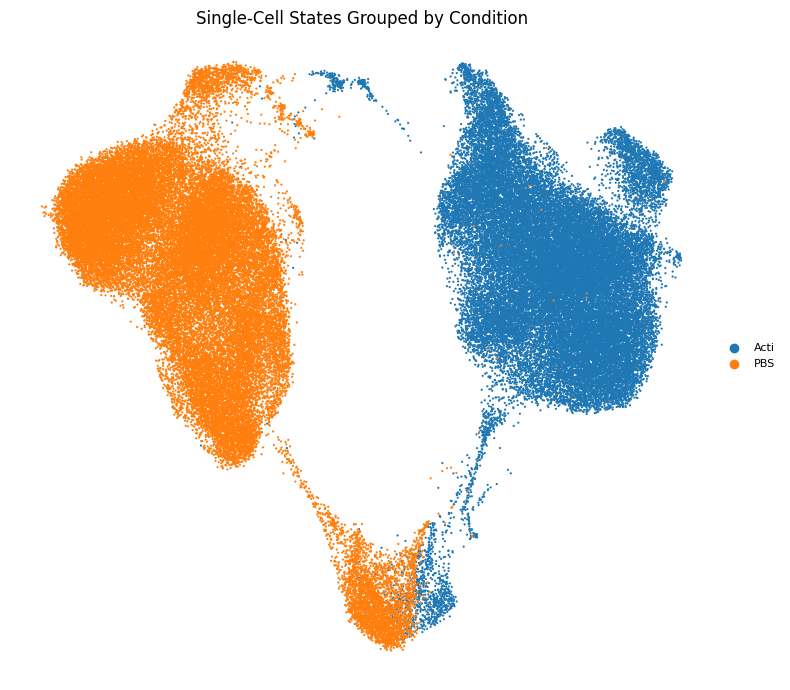

In [2]:


# --- Generate UMAP Plot ---
print(f"Generating UMAP plot, coloring by 'condition'...")

fig, ax = plt.subplots(figsize=umap_figsize)

sc.pl.umap(
    adata,
    color='condition', # Use 'condition' for the original grouping
    # palette=palette,
    ax=ax,
    size=umap_point_size, # Adjust point size (dots per inch)
    legend_loc='right margin', # Place legend labels near clusters (can be 'right margin' too)
    legend_fontsize=umap_legend_fontsize,
    legend_fontoutline=2, # Make legend text easier to read
    frameon=False, # Remove frame around plot
    title='Single-Cell States Grouped by Condition',
    # fontsize=umap_fontsize,
    show=False # Do not show plot immediately, save it first
)

# Improve legend if 'on data' is too crowded
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=umap_legend_fontsize)

plt.tight_layout()

# --- Save Plot ---
output_plot_file = output_plot_dir / 'Fig3a_UMAP_Condition.png'
print(f"Saving plot to: {output_plot_file}")
plt.savefig(output_plot_file, dpi=300, bbox_inches='tight')
print("Plot saved successfully.")
# Optionally show the plot in the notebook/interactive session
# plt.show()

Saving plot to: ../10_27_kai_figure/Figure6a/Fig6a_UMAP_bacth.png
Plot saved successfully.


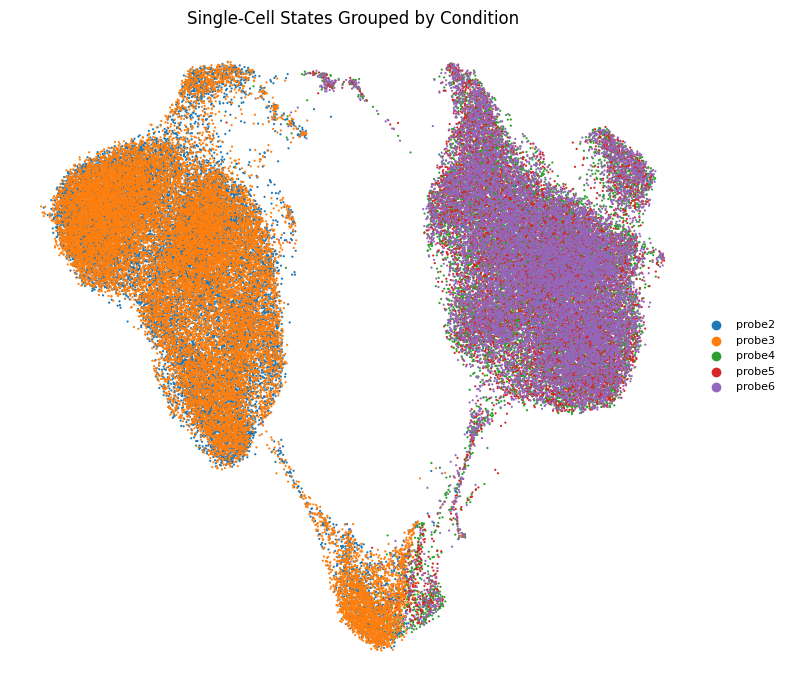

In [3]:
fig, ax = plt.subplots(figsize=umap_figsize)

sc.pl.umap(
    adata,
    color='batch', # Use 'condition' for the original grouping
    # palette=palette,
    ax=ax,
    size=umap_point_size, # Adjust point size (dots per inch)
    legend_loc='right margin', # Place legend labels near clusters (can be 'right margin' too)
    legend_fontsize=umap_legend_fontsize,
    legend_fontoutline=2, # Make legend text easier to read
    frameon=False, # Remove frame around plot
    title='Single-Cell States Grouped by Condition',
    # fontsize=umap_fontsize,
    show=False # Do not show plot immediately, save it first
)

plt.tight_layout()

# --- Save Plot ---
output_plot_file = output_plot_dir / 'Fig6a_UMAP_bacth.png'
print(f"Saving plot to: {output_plot_file}")
plt.savefig(output_plot_file, dpi=200, bbox_inches='tight')
print("Plot saved successfully.")

In [5]:
adata

AnnData object with n_obs × n_vars = 79993 × 2228
    obs: 'n_counts', 'condition', 'batch', 'sample_name', 'sample_key', 'AAVS_ACBE3', 'AAVS4_Any_Pure', 'RORC-rs55895543_het_bystander', 'RORC-rs55895543_het_pure', 'RORC-rs55895543_hom_bystander', 'RORC-rs55895543_hom_pure', 'RORC-rs79051659_het_bystander', 'RORC-rs79051659_het_pure', 'RORC-rs79051659_hom_bystander', 'RORC-rs79051659_hom_pure', 'RORC-rs78703675_het_bystander', 'RORC-rs78703675_het_pure', 'RORC-rs78703675_hom_bystander', 'RORC-rs78703675_hom_pure', 'RORC-rs949969_het_bystander', 'RORC-rs949969_het_pure', 'RORC-rs949969_hom_bystander', 'RORC-rs949969_hom_pure', 'RORC-rs11578418_het_bystander', 'RORC-rs11578418_het_pure', 'RORC-rs11578418_hom_bystander', 'RORC-rs11578418_hom_pure', 'RORC-rs12030974_het_bystander', 'RORC-rs12030974_het_pure', 'RORC-rs12030974_hom_bystander', 'RORC-rs12030974_hom_pure', 'RORC-rs4845604_het_bystander', 'RORC-rs4845604_het_pure', 'RORC-rs4845604_hom_bystander', 'RORC-rs4845604_hom_pure', 'ROR

In [ ]:
# plot marker gene expression
# Check which genes are actually in the adata object
genes_to_plot = ["RORC", "RORC201", "RORC202", 'IL23R','IL1RN','IL1R1','STAT3','IRF4','BATF','TOX','TBX21','BHLHE40','BCL6','CXCR3','CCR6','CCR4','CCR7','TNF','IFNG','IL17A','IL17F','IL21','IL22','IL26','CCL20','IL10']
present_genes = [gene for gene in genes_to_plot if gene in adata.var_names]
missing_genes = [gene for gene in genes_to_plot if gene not in adata.var_names]

if missing_genes:
    print(f"Warning: The following genes were not found in the dataset and will be skipped: {', '.join(missing_genes)}")
plt.rcParams['figure.figsize'] = (6, 6)
if present_genes:
    sc.pl.umap(adata, color=present_genes, size=20, ncols=2, frameon=False, legend_fontsize=20, legend_fontoutline=2, title=present_genes, cmap='viridis', vmax='p99', vmin=0, show=True)
else:
    print("No specified genes were found in the dataset.")

In [7]:
print("Calculating QC metrics per cell...")

# 1. Calculate total UMI counts per cell and add to .obs
#    This sums up all the counts for each row (cell)
adata.obs['total_umi'] = np.array(adata.X.sum(axis=1)).flatten()

# 2. Calculate the number of unique probes detected per cell
#    This counts non-zero entries for each row (cell)
adata.obs['n_probes'] = np.array((adata.X > 0).sum(axis=1)).flatten()

# 3. Calculate UMI per probe for each individual cell
#    This gives a measure of library complexity for each cell.
#    We handle division by zero for any cells with 0 probes by filling the result with 0.
adata.obs['umi_per_probe'] = (
    adata.obs['total_umi'] / adata.obs['n_probes']
).fillna(0)

print("Calculating mean statistics per batch condition...")

# 4. Group by the 'sample_key' (your batch condition) and calculate the mean for our new metrics
#    This gives you the final statistics you requested.
batch_qc_stats = adata.obs.groupby('batch').agg(
    mean_umi_per_cell=('total_umi', 'mean'),
    mean_umi_per_probe_per_cell=('umi_per_probe', 'mean')
)

# --- Display the results ---
print("\n--- QC Metrics by Batch Condition ---")
print(batch_qc_stats)
print("\nDescription:")
print("- mean_umi_per_cell: The average total UMI count per cell for that batch.")
print("- mean_umi_per_probe_per_cell: The average of (total UMIs / detected probes) per cell for that batch.")



Calculating QC metrics per cell...
Calculating mean statistics per batch condition...

--- QC Metrics by Batch Condition ---
        mean_umi_per_cell  mean_umi_per_probe_per_cell
batch                                                 
probe2        1618.459839                     1.518651
probe3        1591.401978                     1.545451
probe4        1651.202271                     1.400654
probe5        1650.876953                     1.417623
probe6        1674.029297                     1.367533

Description:
- mean_umi_per_cell: The average total UMI count per cell for that batch.
- mean_umi_per_probe_per_cell: The average of (total UMIs / detected probes) per cell for that batch.


/tmp/ipykernel_5503/617559605.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_qc_stats = adata.obs.groupby('batch').agg(


Step 6: Performing Leiden clustering...


/tmp/ipykernel_5503/1818066296.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_clust, resolution=0.7, key_added="leiden_clusters", random_state=RANDOM_SEED)


Step 7: Finding marker genes for each cluster...

UMAP colored by Leiden clusters:


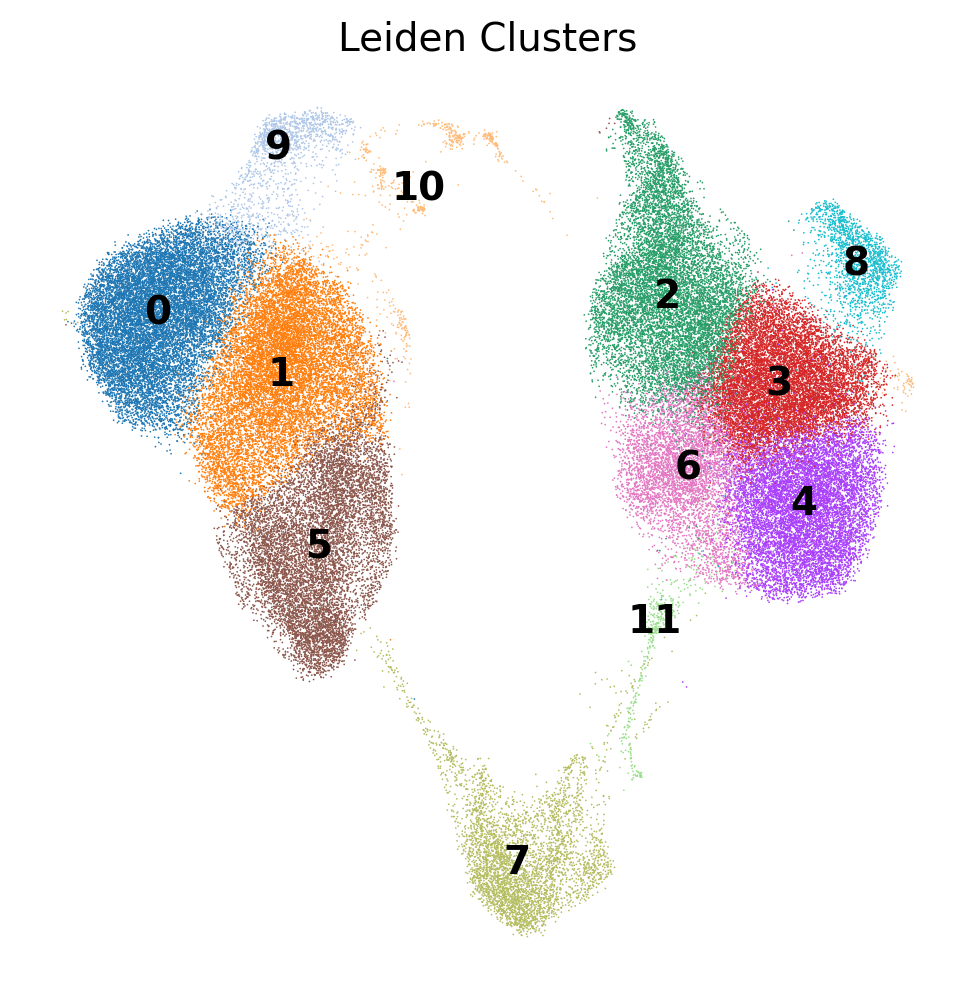


UMAP colored by original sample to check for batch effects:


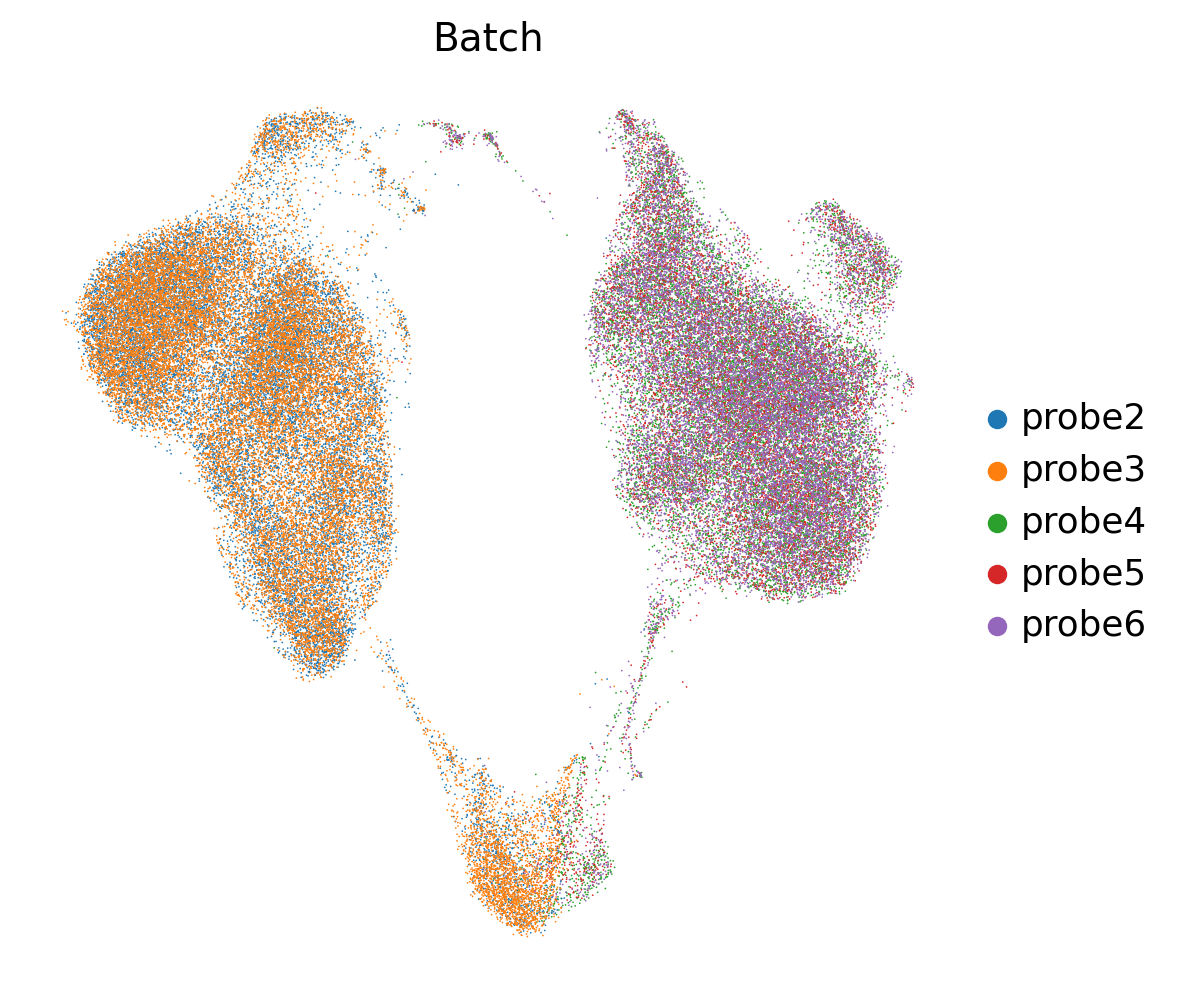


Top marker genes for each cluster:


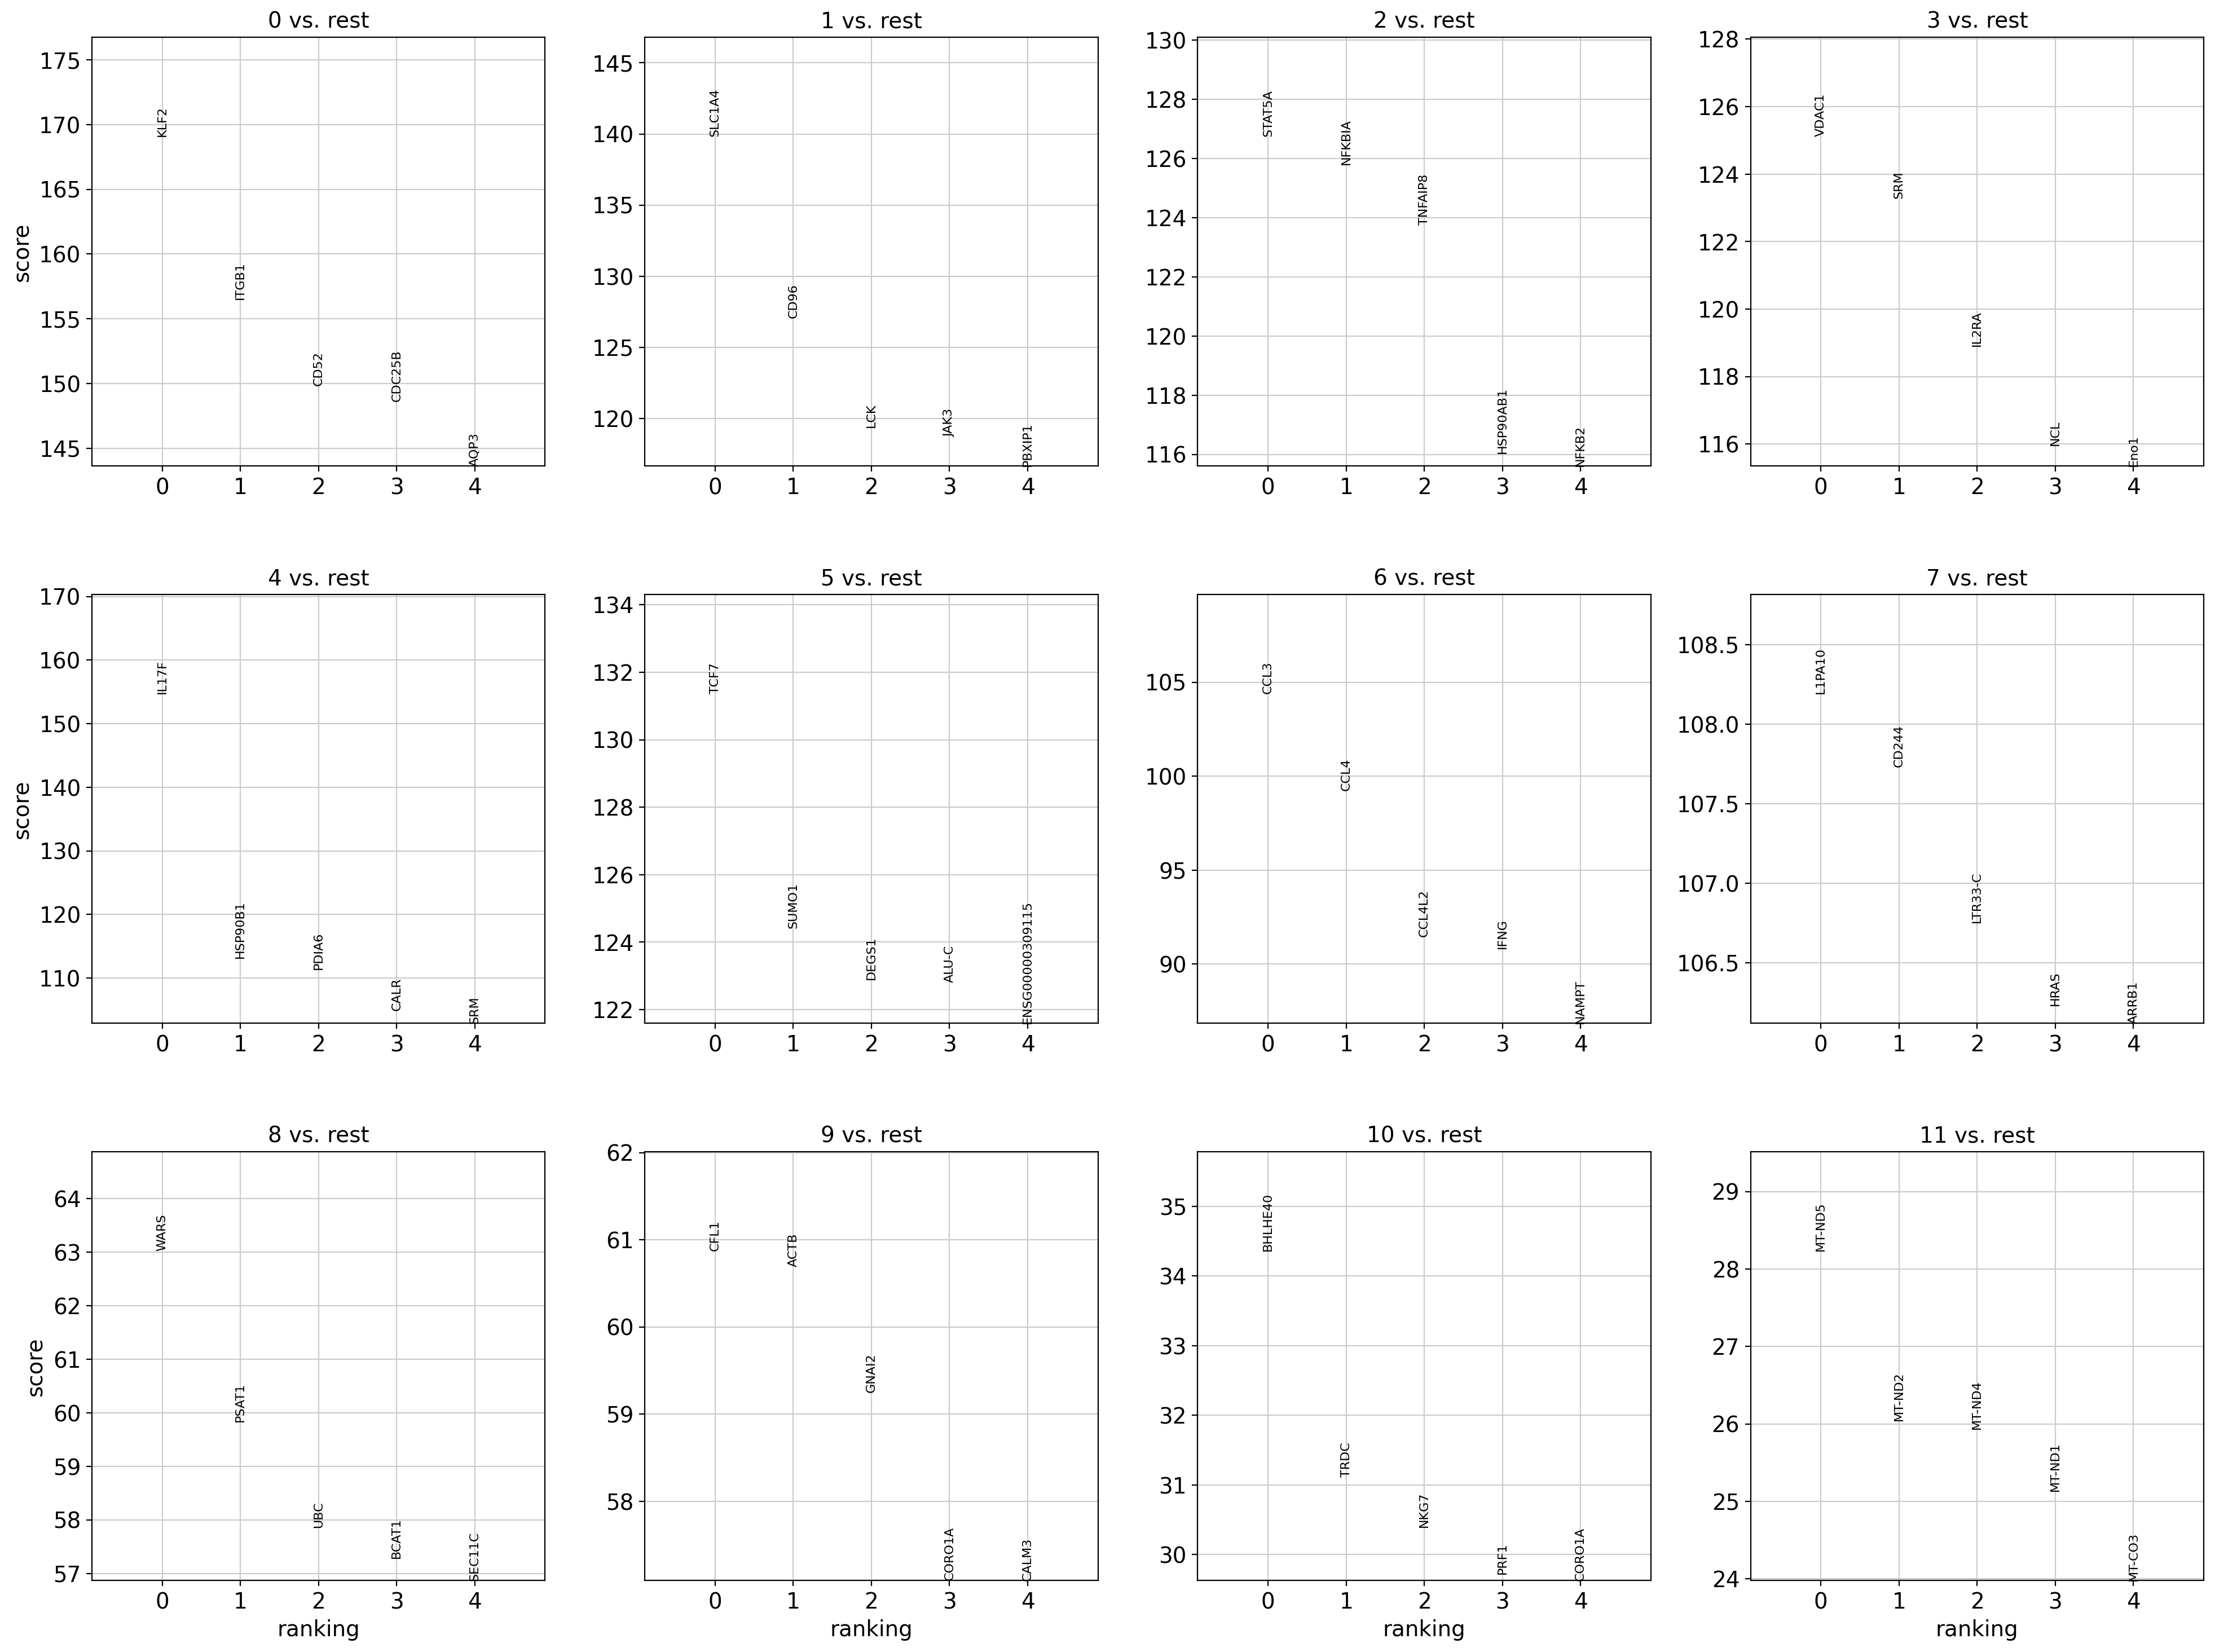

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plotting parameters for better visualization
sc.settings.set_figure_params(dpi=100, frameon=False, figsize=(6, 6), facecolor='white')
# set plotting saving directory
sc.settings.figdir = '../figures/Figure6a'
# Assume 'adata_hypr_merged' is your QC'd, merged AnnData object from previous steps

# --- 1. Preprocessing for Clustering ---
# It's good practice to work on a copy for the clustering-specific steps
adata_clust = adata.copy()


print("Step 6: Performing Leiden clustering...")
# Run the Leiden algorithm to find communities (clusters) in the graph.
# The 'resolution' parameter controls the number of clusters. Higher resolution -> more clusters.
# A value of 0.5 is a good starting point.
sc.tl.leiden(adata_clust, resolution=0.7, key_added="leiden_clusters", random_state=RANDOM_SEED)

# --- 3. Finding Marker Genes ---

print("Step 7: Finding marker genes for each cluster...")
# For each cluster, find genes that are more highly expressed compared to all other clusters.
# We use the Wilcoxon rank-sum test, a standard method.
sc.tl.rank_genes_groups(adata_clust, 'leiden_clusters', method='wilcoxon', use_raw=False)

# --- 4. Visualization and Accessing Results ---

# Plot the UMAP, colored by the new Leiden clusters
print("\nUMAP colored by Leiden clusters:")
sc.pl.umap(adata_clust, color='leiden_clusters', legend_loc='on data', title='Leiden Clusters')
plt.show()

# It's also good practice to check if your clusters are driven by batch
print("\nUMAP colored by original sample to check for batch effects:")
# change the location of the saved file for the sc.pl.umap


sc.pl.umap(adata_clust, color='batch', title='Batch', save=True)
plt.show()

# Visualize the top marker genes for each cluster in a dot plot
print("\nTop marker genes for each cluster:")
sc.pl.rank_genes_groups(
    adata_clust, n_genes=5, sharey=False, save=True)
plt.show()

# --- Accessing the Marker Gene List ---



In [9]:
def get_full_deg_table(adata: sc.AnnData, group_key: str = 'leiden_clusters') -> pd.DataFrame:
    """
    Extracts all marker gene statistics from the rank_genes_groups result
    and returns them as a single, comprehensive DataFrame.

    Args:
        adata: The annotated AnnData object.
        group_key: The key in adata.obs used for clustering (e.g., 'leiden_clusters').

    Returns:
        A Pandas DataFrame with all marker genes and their stats.
    """
    print("Extracting full DEG table...")
    # clear the rank_genes_groups key if it exists
    adata.uns.pop('rank_genes_groups', None)
    # Re-run rank_genes_groups to ensure results are present
    sc.tl.rank_genes_groups(adata, group_key, method='wilcoxon', use_raw=False)
    # Access the unstructured dictionary where results are stored
    dge_results = adata.uns['rank_genes_groups']
    
    all_markers = []
    
    # Iterate through each cluster and its corresponding stats
    for cluster in dge_results['names'].dtype.names:
        # Create a DataFrame for the current cluster
        cluster_df = pd.DataFrame({
            'gene': dge_results['names'][cluster],
            'logfoldchanges': dge_results['logfoldchanges'][cluster],
            'pvals': dge_results['pvals'][cluster],
            'pvals_adj': dge_results['pvals_adj'][cluster],
            'scores': dge_results['scores'][cluster]
        })
        
        # Add a column for the cluster ID
        cluster_df['cluster'] = cluster
        
        all_markers.append(cluster_df)
        
    # Concatenate all cluster-specific DataFrames into one
    full_marker_table = pd.concat(all_markers, ignore_index=True)
    
    # Reorder columns for better readability
    full_marker_table = full_marker_table[['cluster', 'gene', 'logfoldchanges', 'pvals', 'pvals_adj', 'scores']]
    
    print("Extraction complete.")
    return full_marker_table

In [10]:
# check the total UMI distribution for the umap
adata_raw = sc.read_h5ad(adata_file)

In [11]:
adata_raw.obs['total_umi'] = np.array(adata_raw.X.sum(axis=1)).flatten()

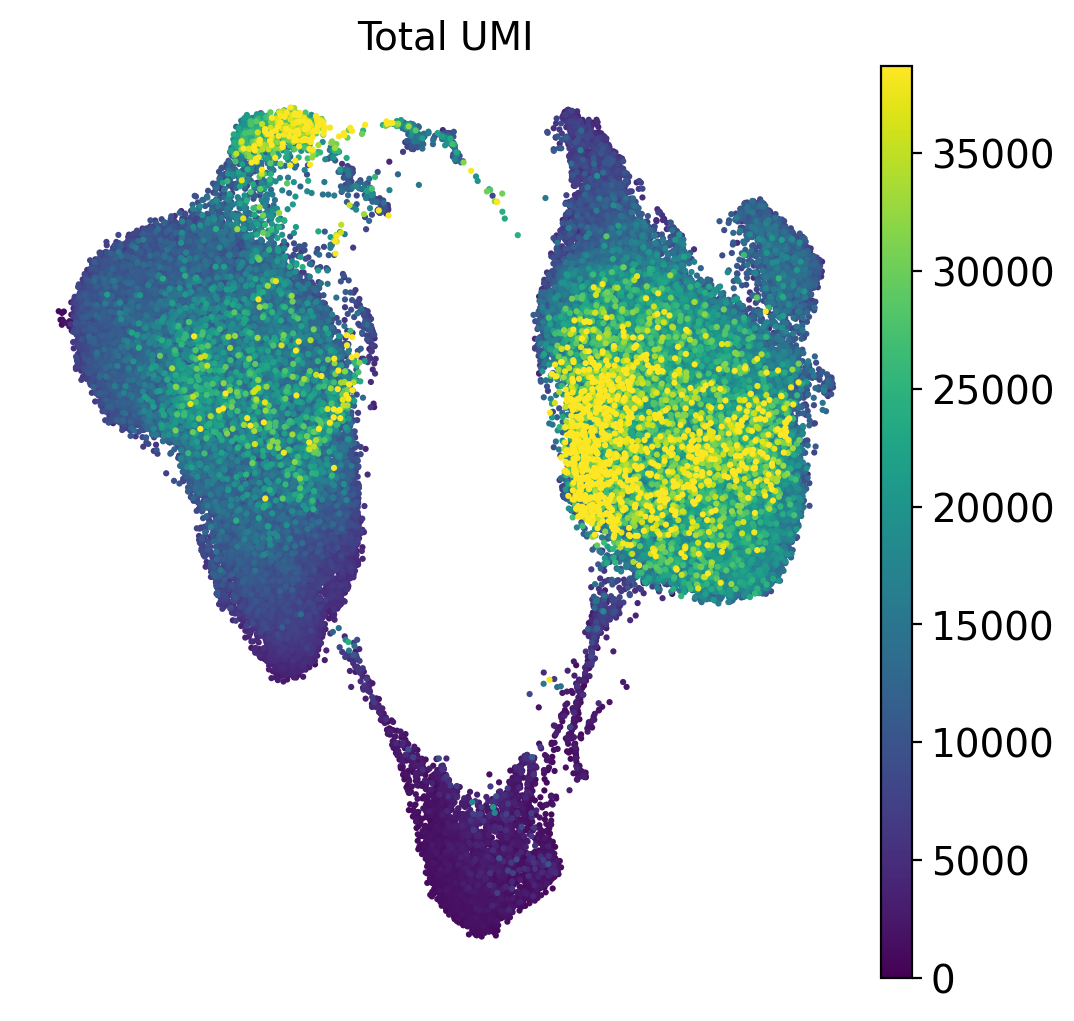

In [12]:
adata_clust.obs['total_umi'] = adata_raw.obs['total_umi']

sc.pl.umap(adata_clust, color=['total_umi'], size=20, frameon=False, legend_fontsize=8, legend_fontoutline=2, title=['Total UMI'], cmap='viridis', vmax='p99', vmin=0, show=True)

In [13]:
# compute the mean UMI per cluster
cluster_umi_stats = adata_clust.obs.groupby('leiden_clusters').agg(
    mean_umi_per_cell=('total_umi', 'mean')
)

print(cluster_umi_stats)

                 mean_umi_per_cell
leiden_clusters                   
0                      8703.142215
1                     10894.386399
2                     12995.743911
3                     13920.504630
4                     15514.896954
5                      8440.574357
6                     18862.005543
7                      1817.667053
8                     10425.982850
9                     19477.832450
10                    12718.504965
11                     5212.850917


/tmp/ipykernel_5503/4115525506.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_umi_stats = adata_clust.obs.groupby('leiden_clusters').agg(


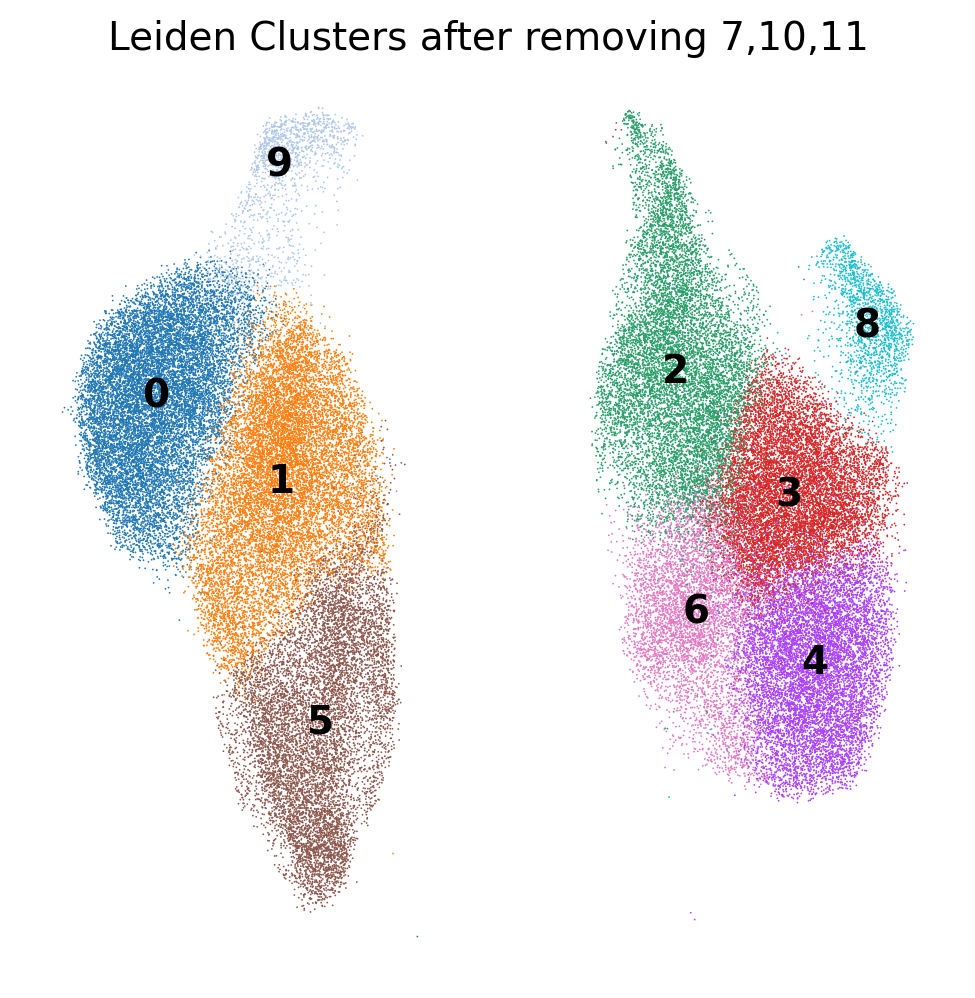

In [14]:
adata_clust_new = adata_clust[~adata_clust.obs['leiden_clusters'].isin(["7", "11", "10"])].copy()

sc.pl.umap(adata_clust_new, color='leiden_clusters', legend_loc='on data', title='Leiden Clusters after removing 7,10,11', save=True)

In [15]:
# remove the cluster 5, 7, 8, and run the DEG again
# rerun the deg


# subset the data to only include cluster 1,2,4, 8
adata_clust_PBS = adata_clust[adata_clust.obs['leiden_clusters'].isin(['0','1','5', '9'])].copy()
adata_clust_Acti = adata_clust[adata_clust.obs['leiden_clusters'].isin(['2','3','4','6','8'])].copy()


In [16]:
adata_clust_PBS.obs["leiden_clusters"].value_counts()


leiden_clusters
0    13353
1    12764
5     9367
9     1510
Name: count, dtype: int64

In [ ]:
# 2. Display the first few rows to verify the result
PBS_deg_table = get_full_deg_table(adata_clust_PBS, group_key='leiden_clusters')
print("\n--- Preview of the Full DEG Table ---")
print(PBS_deg_table.head())

# 3. Save the entire table to a CSV file for your collaborator
output_filename = "../figures/Figure6a/PBS_leiden_cluster_DEG.csv"
PBS_deg_table.to_csv(output_filename, index=False)

print(f"\n✅ Success! All marker genes and statistics have been saved to '{output_filename}'.")
print("This file can be easily opened in Excel or another analysis tool.")

# 2. Display the first few rows to verify the result
Acti_deg_table = get_full_deg_table(adata_clust_Acti, group_key='leiden_clusters')
print("\n--- Preview of the Full DEG Table ---")
print(Acti_deg_table.head())

# 3. Save the entire table to a CSV file for your collaborator
output_filename = "../figures/Figure6a/Acti_leiden_cluster_DEG.csv"
Acti_deg_table.to_csv(output_filename, index=False)

print(f"\n✅ Success! All marker genes and statistics have been saved to '{output_filename}'.")
print("This file can be easily opened in Excel or another analysis tool.")

Extracting full DEG table...


Extraction complete.

--- Preview of the Full DEG Table ---
  cluster    gene  logfoldchanges  pvals  pvals_adj      scores
0       0    KLF2        3.822020    0.0        0.0  141.997604
1       0   ITGB1        1.803556    0.0        0.0  123.148659
2       0   S1PR1        1.618727    0.0        0.0  109.956741
3       0  CDC25B        1.282640    0.0        0.0  103.666756
4       0    AQP3        1.541954    0.0        0.0   98.148796

✅ Success! All marker genes and statistics have been saved to '../10_27_kai_figure/Figure6a/PBS_leiden_cluster_DEG.csv'.
This file can be easily opened in Excel or another analysis tool.
Extracting full DEG table...
Extraction complete.

--- Preview of the Full DEG Table ---
  cluster     gene  logfoldchanges  pvals  pvals_adj     scores
0       2     TCF7        0.435485    0.0        0.0  98.492188
1       2    SUMO1        0.207950    0.0        0.0  80.235779
2       2    HLA-F        0.461362    0.0        0.0  79.480247
3       2   STAT5A     

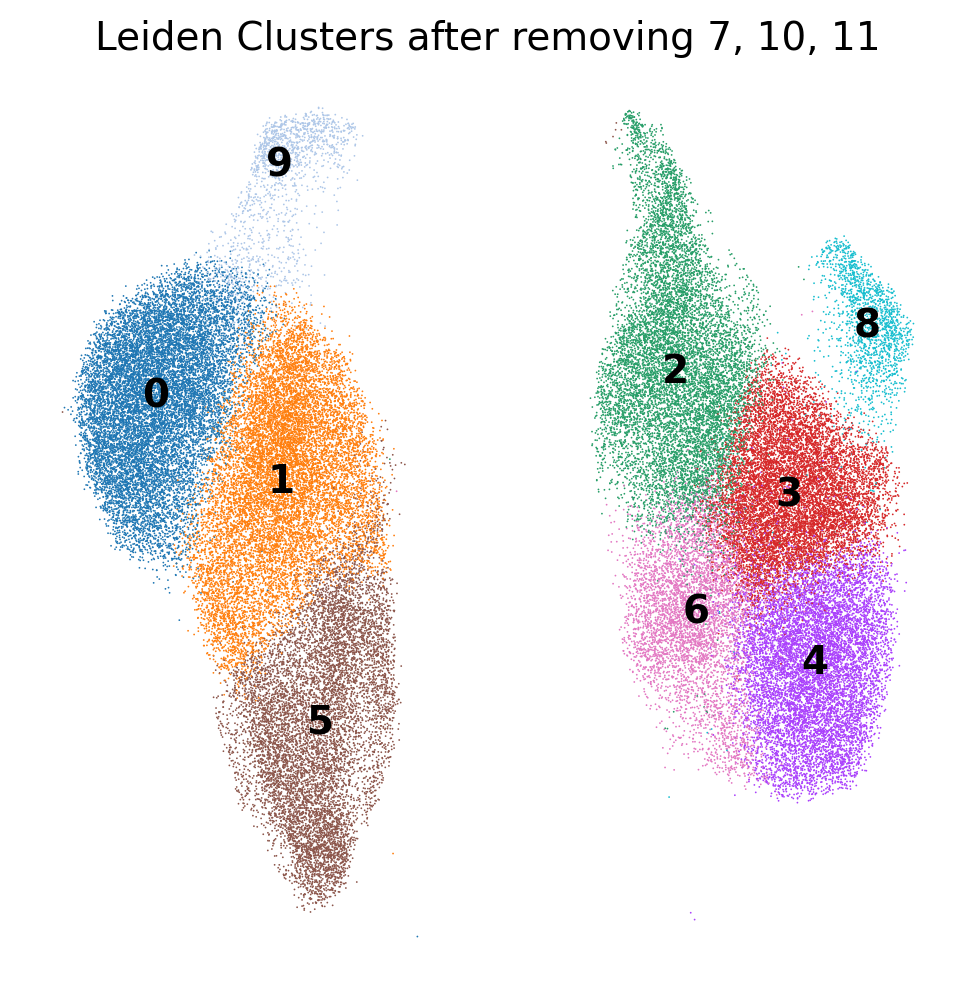

In [18]:
# visualize leiden cluster after removing 5, 7, 8
sc.pl.umap(adata_clust_new, color='leiden_clusters', legend_loc='on data', title='Leiden Clusters after removing 7, 10, 11', save="_leiden.pdf", )
plt.show()

In [ ]:

# plot genes on the adata_clust_new
# plot marker gene expression
# Check which genes are actually in the adata object
genes_to_plot = ["RORC", "RORC201", "RORC202", 'IL23R','IL1RN','IL1R1','STAT3','IRF4','BATF','TOX','TBX21','BHLHE40','BCL6','CXCR3','CCR6','CCR4','CCR7','TNF','IFNG','IL17A','IL17F','IL21','IL22','IL26','CCL20','IL10']
present_genes = [gene for gene in genes_to_plot if gene in adata_clust_new.var_names]
missing_genes = [gene for gene in genes_to_plot if gene not in adata_clust_new.var_names]

if missing_genes:
    print(f"Warning: The following genes were not found in the dataset and will be skipped: {', '.join(missing_genes)}")
plt.rcParams['figure.figsize'] = (6, 6)
if present_genes:
    sc.pl.umap(adata_clust_new, color=present_genes, size=20, ncols=2, frameon=False, legend_fontsize=20, legend_fontoutline=2, title=present_genes, cmap='viridis', vmax='p99', vmin=0, save=True)
else:
    print("No specified genes were found in the dataset.")

In [ ]:
# write the adata_clust_new to h5ad file
import os
os.makedirs("../Data/figure6", exist_ok=True)
adata_clust_new.write_h5ad("../Data/figure6/Normalized_filter_7_10_11.h5ad")

# read the adata_raw, and use the same barcode to filter the adata_raw

adata_raw = sc.read_h5ad(adata_file)
adata_raw_filtered = adata_raw[adata_raw.obs_names.isin(adata_clust_new.obs_names)].copy()
adata_raw_filtered.write_h5ad("../../Data/figure6/Raw_filter_7_10_11.h5ad")